数据处理部分

In [1]:
import pandas as pd
import re

In [2]:
def load_data(filepath):
    texts,labels = [],[]
    with open(filepath,'r',encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:continue
            parts = line.rsplit(';',1)
            if len(parts) == 2:
                texts.append(parts[0].strip())
                labels.append(parts[1].strip())
    return texts,labels

In [3]:
texts,labels = load_data("F:\\album\\emotion detection\\emotions.txt")
df = pd.DataFrame({'text':texts,'label':labels})
print(df.info)

def clean_text(t):
    t = t.lower()
    t = re.sub(r'[^a-zA-Z\s]','',t)
    t = re.sub(r'\s+',' ',t).strip()
    return t

df['cleaned_text'] = df['text'].apply(clean_text)
df[['cleaned_text','label']].to_csv("F:\\album\\emotion detection\\emotion.csv",index=False,encoding='utf-8')



<bound method DataFrame.info of                                                     text    label
0                                i didnt feel humiliated  sadness
1      i can go from feeling so hopeless to so damned...  sadness
2       im grabbing a minute to post i feel greedy wrong    anger
3      i am ever feeling nostalgic about the fireplac...     love
4                                   i am feeling grouchy    anger
...                                                  ...      ...
15995  i just had a very brief time in the beanbag an...  sadness
15996  i am now turning and i feel pathetic that i am...  sadness
15997                     i feel strong and good overall      joy
15998  i feel like this was such a rude comment and i...    anger
15999  i know a lot but i feel so stupid because i ca...  sadness

[16000 rows x 2 columns]>


模型训练，选择LSTM模型

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
#from sklearn.utils.class_weight import compute_class_weight
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.sans-serif']=['SimHei']



In [5]:
df = pd.read_csv("F:\\album\\emotion detection\\emotion.csv")

In [6]:
texts = df['cleaned_text'].tolist()
labels = df['label'].tolist()
unique_labels = ['fear','sadness','anger', 'joy', 'love', 'surprise']
print(unique_labels)

label_counts = Counter(labels)
print("标签分布:")
for lab, cnt in label_counts.items():
    print(f"  {lab}: {cnt}")

text_lens = [len(t.split()) for t in texts]
print(f"文本平均单词数: {np.mean(text_lens):.2f}, 最大: {max(text_lens)}, 最小: {min(text_lens)}")
print("示例文本（前5条）:")
for t in texts[:5]:
    print(f"  {t[:80]}...")

['fear', 'sadness', 'anger', 'joy', 'love', 'surprise']
标签分布:
  sadness: 4666
  anger: 2159
  love: 1304
  surprise: 572
  fear: 1937
  joy: 5362
文本平均单词数: 19.17, 最大: 66, 最小: 2
示例文本（前5条）:
  i didnt feel humiliated...
  i can go from feeling so hopeless to so damned hopeful just from being around so...
  im grabbing a minute to post i feel greedy wrong...
  i am ever feeling nostalgic about the fireplace i will know that it is still on ...
  i am feeling grouchy...


In [7]:
label_to_id = {l: i for i,l in enumerate(unique_labels)}
print(label_to_id)
id_to_label = {i: l for i,l in label_to_id.items()}
y = [label_to_id[l] for l in labels]

X_train,X_temp,y_train,y_temp = train_test_split(texts,y,test_size=0.3,random_state=67,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=76, stratify=y_temp)

print(f"训练集：{len(X_train)}，测试集：{len(X_test)},验证集：{len(X_val)}")

{'fear': 0, 'sadness': 1, 'anger': 2, 'joy': 3, 'love': 4, 'surprise': 5}
训练集：11200，测试集：2400,验证集：2400


In [8]:
def build_vocab(texts,max_vocab = 20000):
    word_counts = Counter()
    for text in texts:
        words = re.findall(r'\b[a-zA-Z]+\b',text.lower())
        word_counts.update(words)
    vocab = {'<PAD>':0,'<UNK>':1}
    for word, _ in word_counts.most_common(max_vocab-2):
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

def text_to_sequence(text, vocab, max_len = 50):
    words = re.findall(r'\b[a-zA-Z]+\b',text.lower())
    seq = [vocab.get(w,vocab['<UNK>']) for w in words[:max_len]]
    if len(seq) < max_len:
        seq += [vocab['<PAD>']] * (max_len - len(seq))
    return seq

vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"词汇量大小：{vocab_size}")

词汇量大小：12561


In [9]:
#创建Dataset
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len = 50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,idx):
        seq = text_to_sequence(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype = torch.long)

batch_size = 64
max_LEN = 60
train_dataset = EmotionDataset(X_train,y_train,vocab,max_LEN)
val_dataset = EmotionDataset(X_val, y_val, vocab,max_LEN)
test_dataset = EmotionDataset(X_test, y_test, vocab,max_LEN)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
#定义LSTM模型
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim = 128, hidden_dim = 256,num_layers = 2,num_classes = len(unique_labels)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim,num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        last_output = out[:,-1,:]
        last_output = self.dropout(last_output)
        return self.fc(last_output)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = LSTMClassifier(vocab_size).to(device)
#类别平衡的效果并不好，注释掉了
#class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
#weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
#criterion = nn.CrossEntropyLoss(weight=weights_tensor)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.005)
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

cuda


tensor(0.)

In [11]:
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for seq, label in loader:
            seq, label = seq.to(device), label.to(device)
            logits = model(seq)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == label).sum().item()
            total += label.size(0)
    return correct / total

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for seq, label in tqdm(loader, desc='Training'):
        seq, label = seq.to(device), label.to(device)
        optimizer.zero_grad()
        logits = model(seq)
        loss = criterion(logits, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_loss(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for seq, label in loader:
            seq, label = seq.to(device), label.to(device)
            logits = model(seq)
            loss = criterion(logits, label)
            total_loss += loss.item()
    return total_loss / len(loader)

In [12]:
EPOCHS = 40
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc =0.0

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    train_acc = compute_accuracy(model, train_loader)
    val_loss = eval_loss(model, val_loader)   # 复用之前定义的 eval_loss
    val_acc = compute_accuracy(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_lstm.pt')

# 加载最佳模型
model.load_state_dict(torch.load('best_lstm.pt'))



Training: 100%|██████████| 175/175 [00:03<00:00, 58.05it/s]


Epoch 1/40, Train Loss: 1.6419, Val Loss: 1.5973, Train Acc: 0.3352, Val Acc: 0.3350


Training: 100%|██████████| 175/175 [00:02<00:00, 70.52it/s]


Epoch 2/40, Train Loss: 1.5844, Val Loss: 1.5777, Train Acc: 0.3353, Val Acc: 0.3350


Training: 100%|██████████| 175/175 [00:02<00:00, 71.99it/s]


...

Training: 100%|██████████| 175/175 [00:02<00:00, 68.32it/s]


Epoch 39/40, Train Loss: 0.0580, Val Loss: 0.5817, Train Acc: 0.9946, Val Acc: 0.8604


Training: 100%|██████████| 175/175 [00:02<00:00, 68.38it/s]


Epoch 40/40, Train Loss: 0.0586, Val Loss: 0.6653, Train Acc: 0.9925, Val Acc: 0.8675


<All keys matched successfully>

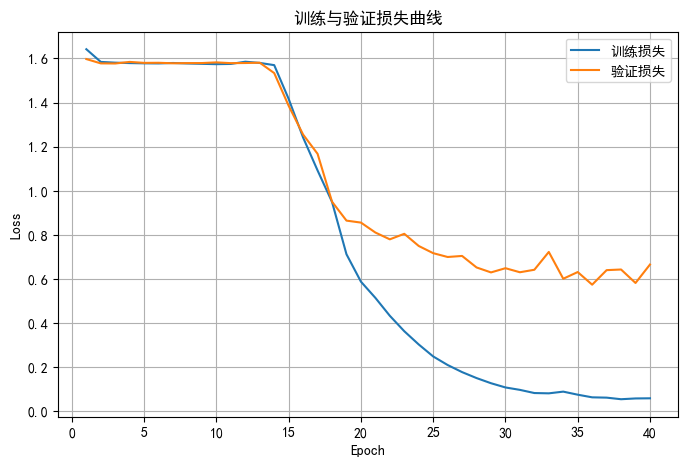

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='训练损失')
plt.plot(range(1, EPOCHS+1), val_losses, label='验证损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练与验证损失曲线')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

In [14]:
def eval_predict(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for seq, label in loader:
            seq, label = seq.to(device), label.to(device)
            logits = model(seq)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(label.cpu().numpy())
    return trues, preds

test_true, test_pred = eval_predict(model, test_loader)
print(f"\n测试集准确率: {accuracy_score(test_true, test_pred):.4f}")
print("\n分类报告:\n", classification_report(test_true, test_pred, target_names=unique_labels))


测试集准确率: 0.8762

分类报告:
               precision    recall  f1-score   support

        fear       0.76      0.81      0.79       290
     sadness       0.94      0.96      0.95       700
       anger       0.83      0.84      0.83       324
         joy       0.93      0.91      0.92       804
        love       0.74      0.73      0.74       196
    surprise       0.76      0.59      0.67        86

    accuracy                           0.88      2400
   macro avg       0.83      0.81      0.81      2400
weighted avg       0.88      0.88      0.88      2400



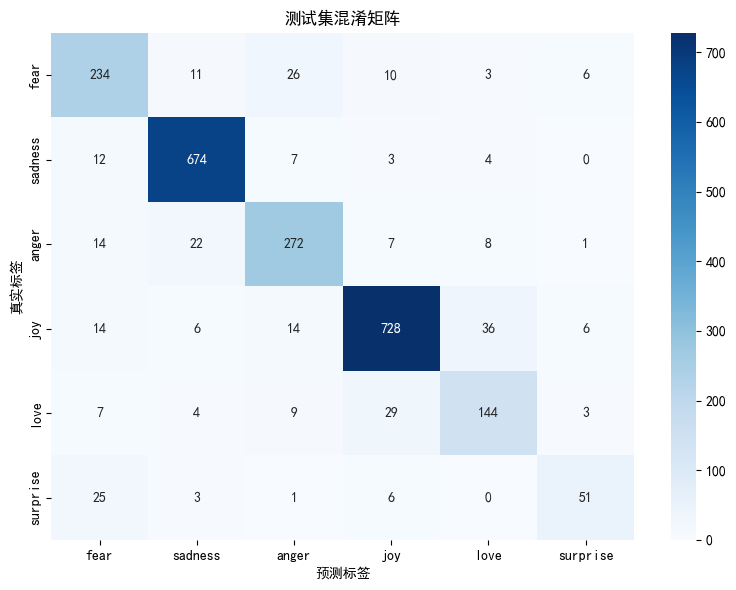

In [15]:
cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('测试集混淆矩阵')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()